In [ ]:
# [auto] project-root setup
import os, sys
from pathlib import Path

# 自动向上查找项目根目录 (含 .gitignore 的文件夹)
_p = Path.cwd().resolve()
while _p != _p.parent and not (_p / '.gitignore').exists():
    _p = _p.parent
PROJECT_ROOT = _p

# 切换 cwd 到项目根, 使所有相对路径 (Stage1_Exploration/, Refined_Results_v4/ 等) 保持有效
os.chdir(PROJECT_ROOT)
# 让 notebooks 能 `from viz_config import VizConfig`
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
print(f'[setup] PROJECT_ROOT = {PROJECT_ROOT}')


图表已保存至: Refined_Results_v4\4.pdf


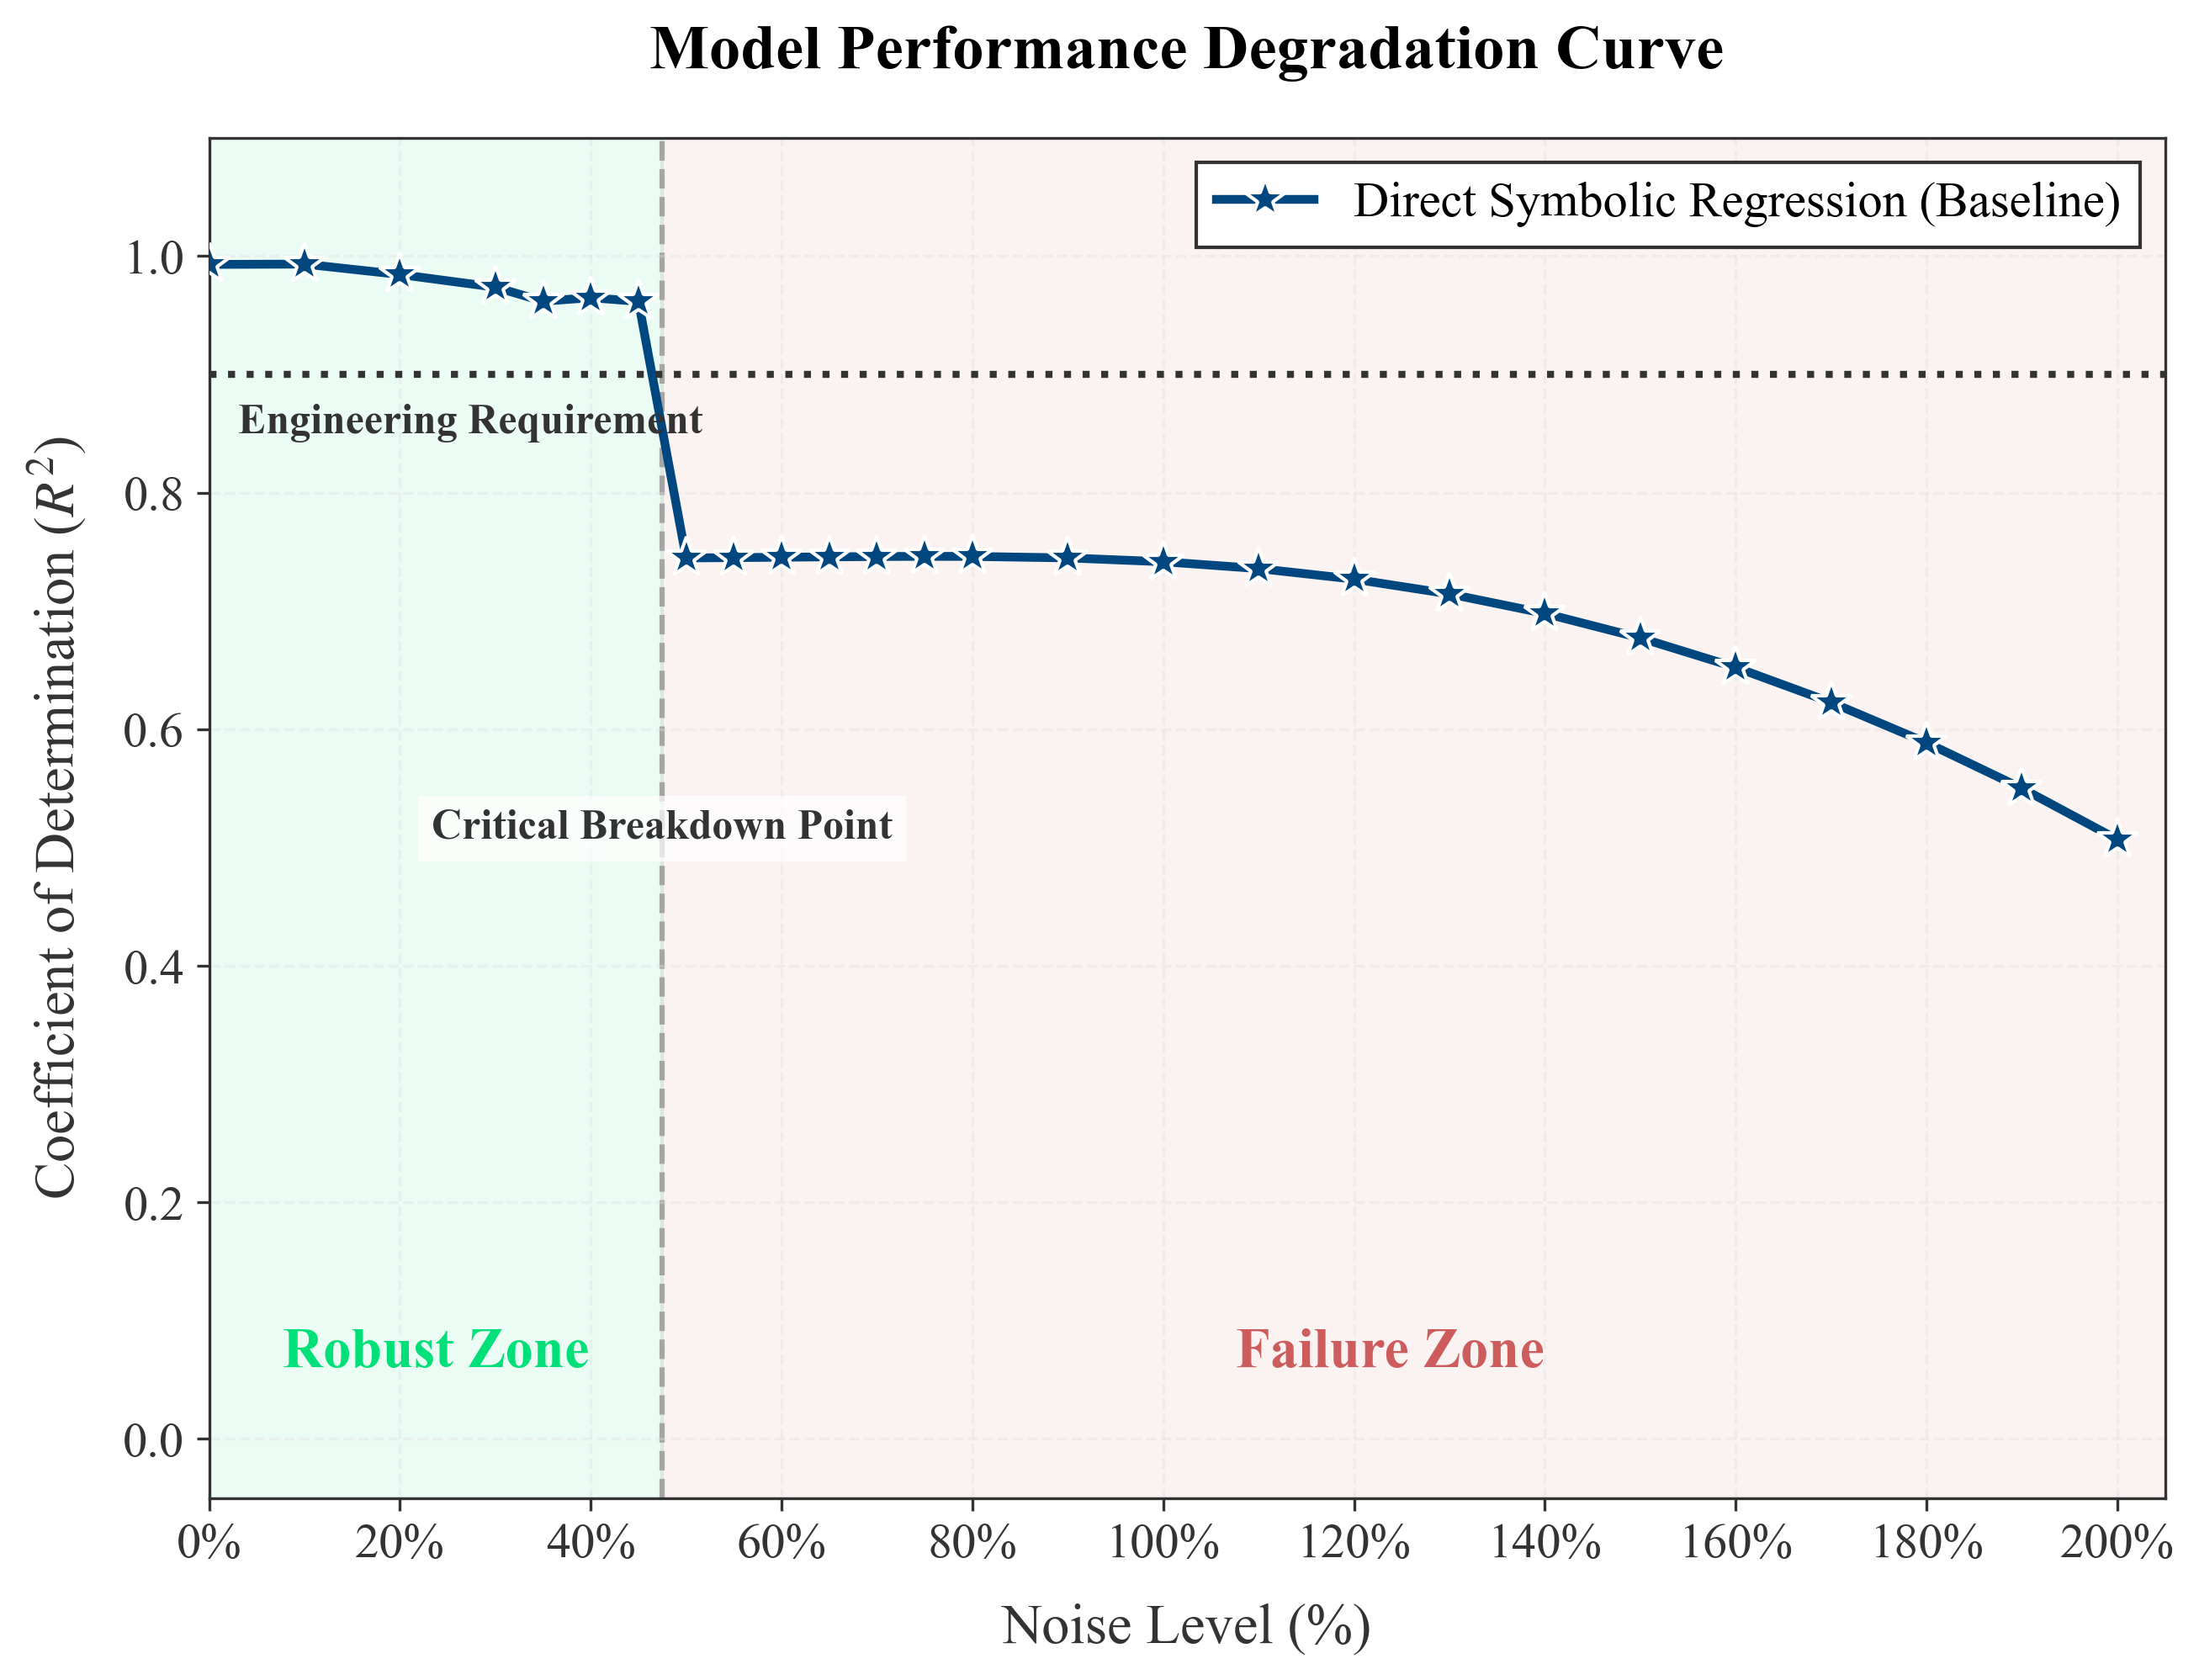

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from viz_config import VizConfig

# ==========================================
# 0. 全局配置与风格设置
# ==========================================
# 引入统一的配色和样式配置文件，确保所有插图符合学术发表标准
VizConfig.set_style()

# 定义结果输出目录，生成的 PDF 将保存在此处
OUTPUT_DIR = "Refined_Results_v4"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# ==========================================
# 1. 数据读取与预处理
# ==========================================
csv_path = os.path.join(OUTPUT_DIR, "final_summary_r2.csv")

# 检查数据文件是否存在，如果不存在则生成模拟数据用于演示代码逻辑
if not os.path.exists(csv_path):
    print(f"提示：未找到文件 {csv_path}，使用模拟数据进行演示。")
    # 构造模拟数据：模拟噪声比例从 0% 到 200% 的变化
    # R2 保持高位直到 45% 左右开始下降，展示模型的鲁棒性边界
    x_raw = np.array([0, 0.1, 0.2, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0])
    y_pysr = np.array([0.99, 0.99, 0.98, 0.97, 0.96, 0.96, 0.96, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.74, 0.72, 0.70, 0.65, 0.59, 0.51])
    df = pd.DataFrame({'Noise_Ratio': x_raw, 'R2_Direct_PySR': y_pysr})
else:
    # 读取真实实验数据
    df = pd.read_csv(csv_path)
    x_raw = df['Noise_Ratio'].values
    y_pysr = df['R2_Direct_PySR'].values

# ==========================================
# 2. 绘图初始化
# ==========================================
fig, ax = plt.subplots(figsize=(10, 7))

# 定义"崩溃点" (Critical Breakdown Point) 的 X 轴位置
# 根据数据特征，模型在 47.5% 左右性能急剧下降
cliff_x = 0.475  
max_x = max(x_raw) if max(x_raw) > 2.0 else 2.0 

# ==========================================
# 3. 核心绘图：背景区域与数据曲线
# ==========================================

# A. 绘制背景区域 (Background Zones)
# 利用不同颜色的背景区分模型的"鲁棒区"和"失效区"
# 左侧：鲁棒区域 (Robust Zone)，使用淡淡的绿色 (COLOR_SUCCESS)
ax.axvspan(xmin=-0.05, xmax=cliff_x, color=VizConfig.COLOR_SUCCESS, alpha=0.08, zorder=0) 
# 右侧：失效区域 (Failure Zone)，使用淡淡的红色 (COLOR_HIGHLIGHT)
ax.axvspan(xmin=cliff_x, xmax=max_x+0.1, color=VizConfig.COLOR_HIGHLIGHT, alpha=0.08, zorder=0)

# B. 绘制临界分界线 (Breakdown Threshold)
# 在崩溃点处绘制一条垂直虚线，作为视觉分割
ax.axvline(x=cliff_x, color=VizConfig.COLOR_SECONDARY, linestyle='--', linewidth=1.5, zorder=1)

# C. 绘制性能衰减曲线 (Performance Curve)
# 展示 R2 随噪声增加的变化趋势
# 使用主色调 (COLOR_MAIN) 绘制连线和数据点
ax.plot(x_raw, y_pysr, marker='o', markersize=8, linewidth=2.5, 
        color=VizConfig.COLOR_MAIN, label='Direct Symbolic Regression (Baseline)', zorder=2,
        markeredgecolor='white', markeredgewidth=1.5)

# ==========================================
# 4. 图表标注与细节美化
# ==========================================

# A. 添加区域文字标注 (Zone Labels)
# 将文字放置在图表底部，避免遮挡数据曲线
text_y_pos = 0.05 
# "Robust Zone" 标注 - 绿色加粗
ax.text(x=cliff_x/2, y=text_y_pos, s="Robust Zone", 
        color=VizConfig.COLOR_SUCCESS, fontsize=VizConfig.LABEL_SIZE, fontweight='bold', ha='center', va='bottom')
# "Failure Zone" 标注 - 红色加粗
ax.text(x=cliff_x + (max_x - cliff_x)/2, y=text_y_pos, s="Failure Zone", 
        color=VizConfig.COLOR_HIGHLIGHT, fontsize=VizConfig.LABEL_SIZE, fontweight='bold', ha='center', va='bottom')

# B. 标注关键崩溃点 (Breakdown Point Annotation)
# 在分界线中间位置添加说明文字，使用白色背景框增加可读性
ax.text(x=cliff_x, y=0.5, s="Critical Breakdown Point", 
        color=VizConfig.COLOR_AXIS, fontsize=12, ha='center', va='bottom', fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# C. X轴刻度优化 (Axis Formatting)
# 设置 X 轴刻度间隔为 20% (0.2)，并将其格式化为百分比字符串 (如 "20%")
x_ticks = np.arange(0, max_x + 0.1, 0.2)
x_tick_labels = [f"{int(val*100)}%" for val in x_ticks]

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_tick_labels, rotation=0, fontsize=VizConfig.TICK_SIZE)
ax.tick_params(axis='y', labelsize=VizConfig.TICK_SIZE)

# ==========================================
# 5. 标题与图例设置
# ==========================================
# 设置坐标轴标签和主标题，支持 LaTeX 公式 (如 $R^2$)
ax.set_xlabel("Noise Level (%)", fontsize=VizConfig.LABEL_SIZE, labelpad=10)
ax.set_ylabel(r"Coefficient of Determination ($R^2$)", fontsize=VizConfig.LABEL_SIZE, labelpad=10)
ax.set_title("Model Performance Degradation Curve", fontsize=VizConfig.TITLE_SIZE, pad=20, fontweight='bold')

# 添加图例，放置在右上角
ax.legend(fontsize=VizConfig.LEGEND_SIZE, loc='upper right', frameon=True, facecolor='white', framealpha=1) 

# 添加网格线，帮助读取数值，使用浅灰色虚线
ax.grid(True, linestyle='--', alpha=0.4, color=VizConfig.COLOR_GRID, zorder=1)

# 设置坐标轴显示范围
ax.set_xlim(0, 2.05) 
ax.set_ylim(-0.05, 1.1) 

# ==========================================
# 6. 保存与显示
# ==========================================
plt.tight_layout()
output_path = os.path.join(OUTPUT_DIR, "4_refined.pdf")
# 保存为高分辨率 PDF (300 DPI)
plt.savefig(output_path, dpi=VizConfig.DPI)

print(f"图表已保存至: {output_path}")
plt.show()